#  Decision Trees

## What is a Decision Tree?
A Decision Tree is a popular, powerful, and intuitive supervised machine learning algorithm used for both classification and regression tasks. 

It mimics human decision-making by breaking down a complex dataset into smaller, manageable choices using a flowchart-like structure. Starting from a broad overview, it splits the data step-by-step based on specific conditions until it reaches a final prediction.

---

## Structure of a Decision Tree
A standard Decision Tree consists of four key components:

1. **Root Node:** The starting point at the top of the tree representing the entire dataset. The algorithm evaluates features here to find the best initial split.
2. **Decision / Internal Nodes:** Points where conditions or tests are applied to the data (e.g., `Sub_Total > 5000`). The data splits further based on the outcome.
3. **Branches:** The lines connecting nodes that represent the pathways or outcomes of the conditions (e.g., True/False or Yes/No).
4. **Leaf / Terminal Nodes:** The final end points of the tree where no further splitting occurs. These hold the final predicted class or value.

---

## How Does a Decision Tree Split Data?
To determine the best feature for splitting, the model uses mathematical metrics to measure "purity" or disorder:

* **Gini Impurity (Classification):** Measures how often a randomly chosen element would be incorrectly labeled. A Gini score of 0 means a pure node (all items belong to a single class). The model looks for splits that minimize Gini impurity.
* **Entropy and Information Gain (Classification):** Entropy measures the disorder or randomness in data. Information Gain measures how much entropy is reduced after a split. Higher information gain means a more effective split.
* **Variance Reduction (Regression):** Used for continuous target variables to minimize the variance within split groups.

---

## Overfitting and Pruning
Left unchecked, a Decision Tree will grow infinitely deep, memorizing every single detail (and noise) of the training data. This causes **overfitting**, where training accuracy is 100% but performance on unseen test data fails.

To prevent this, we use **Pruning**:
* **Pre-Pruning (Early Stopping):** Setting limits before training begins, such as maximum depth (`max_depth`) or minimum samples required to split a node (`min_samples_split`).
* **Post-Pruning:** Allowing the tree to grow fully and then cutting back branches that provide little predictive power.

---

## Advantages of Decision Trees
* **Interpretable (White Box Model):** Easy to understand, visualize, and explain to non-technical stakeholders.
* **Minimal Data Preparation:** Does not require feature scaling (like standardization or normalization) and can handle missing values relatively well.
* **Handles Non-Linearity:** Captures complex, non-linear relationships in data effortlessly.
* **Versatile:** Works seamlessly with both numerical and categorical data types.

## Disadvantages of Decision Trees
* **High Variance / Instability:** Small changes in the training data can completely alter the structure of the tree.
* **Prone to Overfitting:** Without proper depth and constraint tuning, they easily overfit.
* **Class Imbalance Bias:** Can become biased toward majority classes if the dataset is heavily skewed, requiring balancing techniques.

# Import Liberaries 

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score, precision_score, f1_score



### Load Data

In [8]:
df = pd.read_csv("C:/Users/hp/Desktop/Machine_Learning/data.csv")
print("Success! Data loaded.")
df = df.drop_duplicates()


C:\Users\hp\AppData\Local\Temp\ipykernel_8536\1078356737.py:1: DtypeWarning: Columns (0: coupon_code, 1: additional) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("C:/Users/hp/Desktop/Machine_Learning/data.csv")


Success! Data loaded.


### Drop Useless column

In [9]:
useless_cols = ['cashback', 'tabby_payment_id', 'tabby_order_status', 'paymob_intention_id', 'paymob_cents_amount', 'tamara_order_id', 'tamara_checkout_id', 'cko_hpp_id', 'cko_payment_id', 'cko_session_id', 'id', 'old_order_id', 'increment_id', 'customer_email', 'customer_first_name', 'customer_last_name', 'shipping_title', 'shipping_description', 'coupon_code', 'created_at', 'updated_at']
df_clean = df.drop(columns=[col for col in useless_cols if col in df.columns])

df_clean['target'] = df_clean['status'].apply(lambda x: 0 if str(x).strip().lower() == 'completed' else 1)

df_clean['discount_ratio'] = df_clean['discount_amount'] / (df_clean['sub_total'] + 1e-5)
df_clean['tax_ratio'] = df_clean['tax_amount'] / (df_clean['sub_total'] + 1e-5)
df_clean['shipping_ratio'] = df_clean['shipping_amount'] / (df_clean['grand_total'] + 1e-5)
df_clean['avg_item_price'] = df_clean['sub_total'] / (df_clean['total_qty_ordered'] + 1e-5)



### Encoding

In [10]:
core_features = ['sub_total', 'discount_amount', 'tax_amount', 'shipping_amount', 'cod_charges', 'wallet_credit_used', 'total_item_count', 'total_qty_ordered', 'cashback_earned', 'mgmt_fee', 'discount_ratio', 'tax_ratio', 'shipping_ratio', 'avg_item_price', 'channel_name', 'customer_type', 'shipping_method', 'is_guest', 'is_gift', 'cashback_opt_in']
available_features = [col for col in core_features if col in df_clean.columns]

X_raw = df_clean[available_features].copy()
y = df_clean['target']

num_cols = X_raw.select_dtypes(include=['number']).columns
X_raw[num_cols] = X_raw[num_cols].fillna(X_raw[num_cols].median())

cat_cols = X_raw.select_dtypes(include=['object', 'string', 'category']).columns
X_raw[cat_cols] = X_raw[cat_cols].fillna('Missing')

X = pd.get_dummies(X_raw, columns=cat_cols, drop_first=True)



### Split and Train model

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dt_model = DecisionTreeClassifier(max_depth=12, min_samples_split=100, class_weight='balanced', random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)



## Evaluation

In [12]:
print("=" * 50)
print(" DECISION TREE PERFORMANCE (FULL DATASET) ")
print("=" * 50)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_dt):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))
print("=" * 50)

 DECISION TREE PERFORMANCE (FULL DATASET) 
Accuracy Score: 0.7638

Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.71      0.65      9247
           1       0.85      0.79      0.82     19994

    accuracy                           0.76     29241
   macro avg       0.73      0.75      0.74     29241
weighted avg       0.78      0.76      0.77     29241



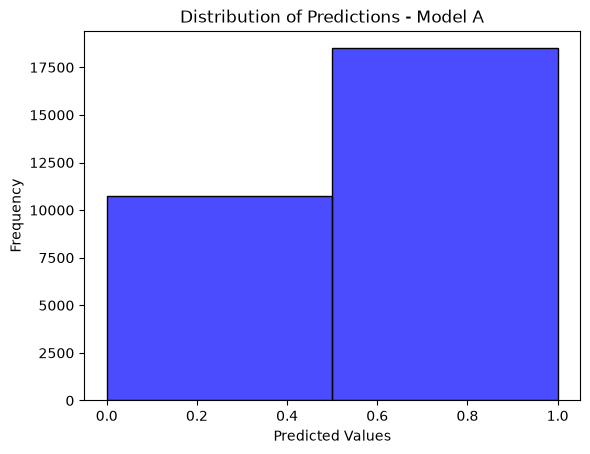

In [14]:
sns.histplot(y_pred_dt, bins=2, kde=False, color='blue', alpha=0.7)
plt.title("Distribution of Predictions - Model A")
plt.xlabel("Predicted Values")
plt.ylabel("Frequency")
plt.show()

<Axes: >

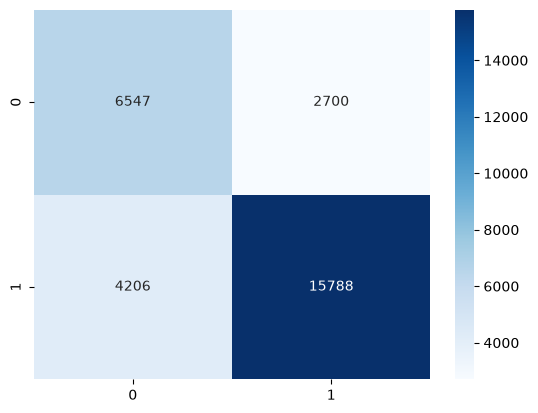

In [15]:
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Blues')

In [17]:
import pickle
pickle.dump(dt_model, open("saved_models/dt.pkl", "wb"))